In [ ]:
# Standard library
import os
import random
import pickle
from base64 import b64decode

# Third-party
import numpy as np
import torch
import torchaudio
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import kagglehub
from IPython.display import Javascript, display
from google.colab import output
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from speechbrain.inference.speaker import EncoderClassifier

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 57.6 MB/s eta 0:00:00
Using device: cuda


In [ ]:
!mkdir -p ~/.kaggle
!echo "KGAT_bbb77dceb1d5cf75ad61e07a205d1b4e" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

dataset_path = kagglehub.dataset_download("vjcalling/speaker-recognition-audio-dataset")
print("Dataset downloaded to:", dataset_path)

DATA_ROOT = os.path.join(dataset_path, "50_speakers_audio_data")
speakers = sorted(
    [d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))]
)

print(f"Number of speakers found: {len(speakers)}")
print(f"Speaker names: {speakers[:10]} ...")

100%|██████████| 3.64G/3.64G [03:01<00:00, 21.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1
Number of speakers found: 50
Speaker names: ['Speaker0026', 'Speaker0027', 'Speaker0028', 'Speaker0029', 'Speaker0030', 'Speaker0031', 'Speaker0032', 'Speaker0033', 'Speaker0034', 'Speaker0035'] ...


In [ ]:
ecapa_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_ecapa"
)

print("ECAPA-TDNN model loaded successfully.")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


ECAPA-TDNN model loaded successfully.


In [ ]:
sample_spk = speakers[0]
sample_file = os.listdir(os.path.join(DATA_ROOT, sample_spk))[0]
sample_path = os.path.join(DATA_ROOT, sample_spk, sample_file)

signal, fs = torchaudio.load(sample_path)
print(f"Loaded audio shape: {signal.shape}, sample rate: {fs}")

embedding = ecapa_model.encode_batch(signal)
print(f"Embedding shape: {embedding.shape}")

Loaded audio shape: torch.Size([1, 1323008]), sample rate: 22050
Embedding shape: torch.Size([1, 1, 192])


In [ ]:
def get_ecapa_embedding(file_path, target_sr=16000):
    """
    Loads an audio file, resamples to 16kHz if needed, and returns its
    ECAPA-TDNN embedding as a flat NumPy array.
    """
    signal, sr = torchaudio.load(file_path)

    # Resample if the file isn't already at our target rate
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        signal = resampler(signal)

    # If the file has multiple channels (stereo), average them into mono
    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)

    with torch.no_grad():
        embedding = ecapa_model.encode_batch(signal)

    return embedding.squeeze().cpu().numpy()  # flatten to shape (192,)


# Test on the same file as before, now correctly resampled
test_embedding = get_ecapa_embedding(sample_path)
print(f"Embedding shape: {test_embedding.shape}")  # expect: (192,)
print(f"Embedding norm (length): {np.linalg.norm(test_embedding):.4f}")

Embedding shape: (192,)
Embedding norm (length): 283.4953


In [ ]:
# Compare: embedding from raw (unresampled) vs properly resampled audio
signal_raw, sr_raw = torchaudio.load(sample_path)
with torch.no_grad():
    embedding_raw = ecapa_model.encode_batch(signal_raw).squeeze().cpu().numpy()

embedding_resampled = get_ecapa_embedding(sample_path)

difference = np.linalg.norm(embedding_raw - embedding_resampled)
print(f"Difference between raw and resampled embeddings: {difference:.4f}")

Difference between raw and resampled embeddings: 382.6878


In [ ]:
# Cell 7
NUM_ENROLLMENT_SAMPLES = 5
NUM_ENROLLMENT_SPEAKERS = (
    15  # keep consistent with our earlier CNN evaluation for a fair comparison
)

random.seed(42)
enrollment_speakers = random.sample(speakers, NUM_ENROLLMENT_SPEAKERS)

voiceprints_ecapa = {}

for spk in enrollment_speakers:
    spk_path = os.path.join(DATA_ROOT, spk)
    spk_files = os.listdir(spk_path)

    # Use the first NUM_ENROLLMENT_SAMPLES files for enrollment
    enrollment_files = [
        os.path.join(spk_path, f) for f in spk_files[:NUM_ENROLLMENT_SAMPLES]
    ]

    embeddings = [get_ecapa_embedding(f) for f in enrollment_files]
    embeddings = np.array(embeddings)

    voiceprint = embeddings.mean(axis=0)
    voiceprint = voiceprint / np.linalg.norm(
        voiceprint
    )  # normalize for fair cosine similarity later

    voiceprints_ecapa[spk] = voiceprint
    print(f"Enrolled {spk} using {NUM_ENROLLMENT_SAMPLES} samples.")

print(f"\nTotal voiceprints stored: {len(voiceprints_ecapa)}")

# Save enrollment speaker list immediately, so this stays consistent even across session restarts
with open("ecapa_enrollment_metadata.pkl", "wb") as f:
    pickle.dump({"enrollment_speakers": enrollment_speakers}, f)

Enrolled Speaker_0015 using 5 samples.
Enrolled Speaker0033 using 5 samples.
Enrolled Speaker0027 using 5 samples.
Enrolled Speaker0043 using 5 samples.
Enrolled Speaker0041 using 5 samples.
Enrolled Speaker0040 using 5 samples.
Enrolled Speaker0034 using 5 samples.
Enrolled Speaker0032 using 5 samples.
Enrolled Speaker_0009 using 5 samples.
Enrolled Speaker0031 using 5 samples.
Enrolled Speaker_0012 using 5 samples.
Enrolled Speaker_0002 using 5 samples.
Enrolled Speaker0028 using 5 samples.
Enrolled Speaker_0023 using 5 samples.
Enrolled Speaker_0025 using 5 samples.

Total voiceprints stored: 15


In [ ]:
# Cell 8
NUM_TEST_SAMPLES_PER_SPEAKER = 15  # kept modest since ECAPA inference + resampling is heavier per-file than our CNN

genuine_scores_ecapa = []
impostor_scores_ecapa = []

for spk in enrollment_speakers:
    voiceprint = voiceprints_ecapa[spk]
    spk_path = os.path.join(DATA_ROOT, spk)
    spk_files = os.listdir(spk_path)

    # Genuine attempts: other files from the SAME speaker, not used in enrollment
    genuine_end = NUM_ENROLLMENT_SAMPLES + NUM_TEST_SAMPLES_PER_SPEAKER
    genuine_files = spk_files[NUM_ENROLLMENT_SAMPLES:genuine_end]
    for f in genuine_files:
        emb = get_ecapa_embedding(os.path.join(spk_path, f))
        score = np.dot(emb / np.linalg.norm(emb), voiceprint)
        genuine_scores_ecapa.append(score)

    # Impostor attempts: files from OTHER enrolled speakers
    other_speakers = [s for s in enrollment_speakers if s != spk]
    for other_spk in other_speakers:
        other_path = os.path.join(DATA_ROOT, other_spk)
        other_files = os.listdir(other_path)[: NUM_TEST_SAMPLES_PER_SPEAKER // 5]
        for f in other_files:
            emb = get_ecapa_embedding(os.path.join(other_path, f))
            score = np.dot(emb / np.linalg.norm(emb), voiceprint)
            impostor_scores_ecapa.append(score)

genuine_scores_ecapa = np.array(genuine_scores_ecapa)
impostor_scores_ecapa = np.array(impostor_scores_ecapa)

print(f"Collected {len(genuine_scores_ecapa)} genuine attempt scores")
print(f"Collected {len(impostor_scores_ecapa)} impostor attempt scores")
print(
    f"\nGenuine scores  — mean: {genuine_scores_ecapa.mean():.4f} | std: {genuine_scores_ecapa.std():.4f}"
)
print(
    f"Impostor scores — mean: {impostor_scores_ecapa.mean():.4f} | std: {impostor_scores_ecapa.std():.4f}"
)

# Save results immediately so a session restart doesn't lose this expensive computation
with open("ecapa_evaluation_scores.pkl", "wb") as f:
    pickle.dump(
        {
            "genuine_scores": genuine_scores_ecapa,
            "impostor_scores": impostor_scores_ecapa,
        },
        f,
    )

Collected 225 genuine attempt scores
Collected 630 impostor attempt scores

Genuine scores  — mean: 0.8948 | std: 0.1678
Impostor scores — mean: 0.1164 | std: 0.1018


Equal Error Rate (EER): 2.46%
Threshold at EER point: 0.34


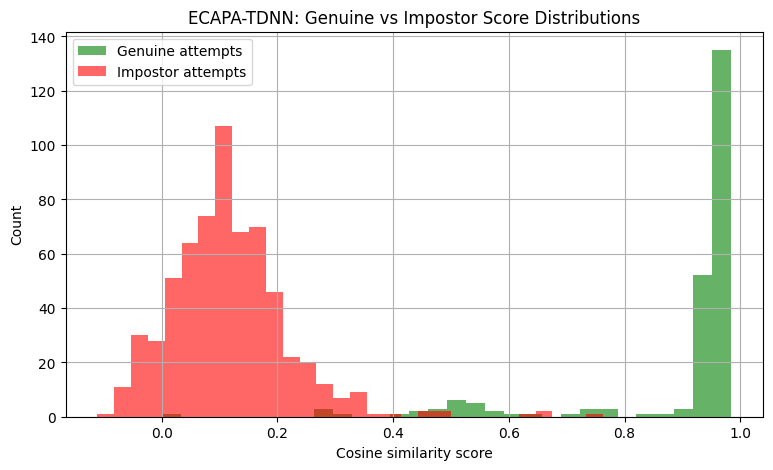

In [ ]:
# Cell 9
thresholds = np.arange(0.0, 1.01, 0.01)

far_list_ecapa = []
frr_list_ecapa = []

for t in thresholds:
    far = np.mean(impostor_scores_ecapa >= t)
    frr = np.mean(genuine_scores_ecapa < t)
    far_list_ecapa.append(far)
    frr_list_ecapa.append(frr)

far_list_ecapa = np.array(far_list_ecapa)
frr_list_ecapa = np.array(frr_list_ecapa)

diff = np.abs(far_list_ecapa - frr_list_ecapa)
eer_idx = np.argmin(diff)
eer_threshold_ecapa = thresholds[eer_idx]
eer_value_ecapa = (far_list_ecapa[eer_idx] + frr_list_ecapa[eer_idx]) / 2

print(f"Equal Error Rate (EER): {eer_value_ecapa*100:.2f}%")
print(f"Threshold at EER point: {eer_threshold_ecapa:.2f}")

plt.figure(figsize=(9, 5))
plt.hist(
    genuine_scores_ecapa, bins=30, alpha=0.6, label="Genuine attempts", color="green"
)
plt.hist(
    impostor_scores_ecapa, bins=30, alpha=0.6, label="Impostor attempts", color="red"
)
plt.xlabel("Cosine similarity score")
plt.ylabel("Count")
plt.title("ECAPA-TDNN: Genuine vs Impostor Score Distributions")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 10
FINAL_THRESHOLD_ECAPA = eer_threshold_ecapa  # 0.35

with open("voiceprints_ecapa.pkl", "wb") as f:
    pickle.dump(voiceprints_ecapa, f)

with open("threshold_ecapa.pkl", "wb") as f:
    pickle.dump(FINAL_THRESHOLD_ECAPA, f)

print(f"Voiceprints saved: {os.path.exists('voiceprints_ecapa.pkl')}")
print(f"Threshold saved: {FINAL_THRESHOLD_ECAPA}")

Voiceprints saved: True
Threshold saved: 0.34


In [ ]:
# Cell 11
def run_inference_ecapa(
    audio_file_path,
    claimed_identity,
    ecapa_model,
    voiceprints,
    threshold,
    target_sr=16000,
):
    """
    Runs full inference using ECAPA-TDNN: takes a raw audio file, compares it against
    a claimed identity's stored voiceprint, and returns an authentication decision.
    """
    if claimed_identity not in voiceprints:
        return {
            "error": f"'{claimed_identity}' is not enrolled. Available identities: {list(voiceprints.keys())}"
        }

    signal, sr = torchaudio.load(audio_file_path)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        signal = resampler(signal)

    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)

    with torch.no_grad():
        embedding = ecapa_model.encode_batch(signal).squeeze().cpu().numpy()

    embedding = embedding / np.linalg.norm(
        embedding
    )  # normalize, same as our stored voiceprints

    stored_voiceprint = voiceprints[claimed_identity]
    similarity = float(np.dot(embedding, stored_voiceprint))

    decision = similarity >= threshold

    return {
        "claimed_identity": claimed_identity,
        "accepted": decision,
        "confidence": round(similarity, 4),
        "threshold_used": threshold,
    }


print("run_inference_ecapa() function defined.")

run_inference_ecapa() function defined.


In [ ]:
# Cell 12
available_speakers = list(voiceprints_ecapa.keys())
test_spk = available_speakers[0]
impostor_spk = available_speakers[1]

print(f"Testing genuine: {test_spk}")
spk_path = os.path.join(DATA_ROOT, test_spk)
test_file = os.listdir(spk_path)[
    10
]  # a file NOT used in enrollment (enrollment used first 5)
result = run_inference_ecapa(
    os.path.join(spk_path, test_file),
    claimed_identity=test_spk,
    ecapa_model=ecapa_model,
    voiceprints=voiceprints_ecapa,
    threshold=0.35,
)
print("Genuine result:", result)

print(f"\nTesting impostor: {impostor_spk}'s voice against {test_spk}'s voiceprint")
imp_path = os.path.join(DATA_ROOT, impostor_spk)
imp_file = os.listdir(imp_path)[10]
result = run_inference_ecapa(
    os.path.join(imp_path, imp_file),
    claimed_identity=test_spk,
    ecapa_model=ecapa_model,
    voiceprints=voiceprints_ecapa,
    threshold=0.35,
)
print("Impostor result:", result)

Testing genuine: Speaker_0015
Genuine result: {'claimed_identity': 'Speaker_0015', 'accepted': True, 'confidence': 0.9783, 'threshold_used': 0.35}

Testing impostor: Speaker0033's voice against Speaker_0015's voiceprint
Impostor result: {'claimed_identity': 'Speaker_0015', 'accepted': False, 'confidence': -0.0391, 'threshold_used': 0.35}


In [ ]:
# Cell 13

RECORD_JS = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time));

var record = time => new Promise(async resolve => {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  const recorder = new MediaRecorder(stream);
  const chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();
  await sleep(time);
  recorder.onstop = async () => {
    const blob = new Blob(chunks);
    const reader = new FileReader();
    reader.onloadend = () => resolve(reader.result);
    reader.readAsDataURL(blob);
    stream.getTracks().forEach(t => t.stop());
  };
  recorder.stop();
});
"""


def record_audio(filename, seconds=4):
    """
    Records audio from the browser microphone for the given duration
    and saves it as a .wav file.
    """
    display(Javascript(RECORD_JS))
    print(f"Recording for {seconds} seconds... speak now!")
    data = output.eval_js(f"record({seconds * 1000})")
    binary = b64decode(data.split(",")[1])

    # Save the raw recording, then convert to a clean .wav using soundfile
    temp_webm = "temp_recording.webm"
    with open(temp_webm, "wb") as f:
        f.write(binary)

    # Convert webm to wav using librosa (handles the format conversion)
    waveform, sr = librosa.load(temp_webm, sr=16000)
    sf.write(filename, waveform, sr)

    print(f"Saved recording to {filename}")
    return filename


print("record_audio() function ready.")

record_audio() function ready.


In [ ]:
# Cell 14
my_name = "Maryam"  # change if you'd like a different label
num_enrollment_samples = 5

my_embeddings = []

for i in range(num_enrollment_samples):
    input(
        f"Press Enter, then speak clearly for sample {i+1}/{num_enrollment_samples}..."
    )
    filename = f"my_sample_{i}.wav"
    record_audio(filename, seconds=4)

    emb = get_ecapa_embedding(filename)
    my_embeddings.append(emb)
    print(f"Sample {i+1} captured.\n")

my_embeddings = np.array(my_embeddings)
my_voiceprint = my_embeddings.mean(axis=0)
my_voiceprint = my_voiceprint / np.linalg.norm(my_voiceprint)

voiceprints_ecapa[my_name] = my_voiceprint

print(
    f"\n'{my_name}' enrolled successfully using {num_enrollment_samples} real recordings!"
)

Press Enter, then speak clearly for sample 1/5...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Saved recording to my_sample_0.wav
Sample 1 captured.

Press Enter, then speak clearly for sample 2/5...


...

/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Saved recording to my_sample_3.wav
Sample 4 captured.

Press Enter, then speak clearly for sample 5/5...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!
Saved recording to my_sample_4.wav
Sample 5 captured.


'Maryam' enrolled successfully using 5 real recordings!


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Cell 15
input("Press Enter, then speak your test phrase...")
record_audio("my_test.wav", seconds=4)

result = run_inference_ecapa(
    "my_test.wav",
    claimed_identity=my_name,
    ecapa_model=ecapa_model,
    voiceprints=voiceprints_ecapa,
    threshold=0.35,
)
print("\nYour authentication result:", result)

Press Enter, then speak your test phrase...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!
Saved recording to my_test.wav

Your authentication result: {'claimed_identity': 'Maryam', 'accepted': True, 'confidence': 0.7663, 'threshold_used': 0.35}


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Cell 16
input("Someone else: press Enter, then speak...")
record_audio("impostor_test.wav", seconds=4)

result = run_inference_ecapa(
    "impostor_test.wav",
    claimed_identity="Maryam",
    ecapa_model=ecapa_model,
    voiceprints=voiceprints_ecapa,
    threshold=0.35,
)
print("\nImpostor authentication result:", result)

Someone else: press Enter, then speak...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!
Saved recording to impostor_test.wav

Impostor authentication result: {'claimed_identity': 'Maryam', 'accepted': True, 'confidence': 0.7437, 'threshold_used': 0.35}


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Training

In [ ]:
# Cell 17
for param in ecapa_model.mods.embedding_model.parameters():
    param.requires_grad = False

unfrozen_count = 0
for name, param in ecapa_model.mods.embedding_model.named_parameters():
    if "fc" in name or "asp" in name:
        param.requires_grad = True
        unfrozen_count += 1

print(f"Unfroze {unfrozen_count} parameter groups in the final layers.")

# Sanity check — print the actual structure if unfrozen_count is 0, so we can find correct layer names
if unfrozen_count == 0:
    print("\nNo layers matched — inspecting model structure to find correct names:")
    for name, _ in ecapa_model.mods.embedding_model.named_parameters():
        print(name)

Unfroze 10 parameter groups in the final layers.


In [ ]:
# Cell 18
random.seed(42)

# Hold out 5 speakers for genuine generalization testing
all_speakers_ft = speakers.copy()
random.shuffle(all_speakers_ft)

held_out_ft = all_speakers_ft[:5]
training_speakers_ft = all_speakers_ft[5:]

speaker_files_ft = {}
for spk in training_speakers_ft:
    spk_path = os.path.join(DATA_ROOT, spk)
    files = [os.path.join(spk_path, f) for f in os.listdir(spk_path)]
    random.shuffle(files)

    split_idx = int(0.8 * len(files))
    speaker_files_ft[spk] = {"train": files[:split_idx], "val": files[split_idx:]}

print(f"Held-out speakers: {held_out_ft}")
print(f"Training speakers: {len(training_speakers_ft)}")
for spk in training_speakers_ft[:3]:
    print(
        f"{spk}: {len(speaker_files_ft[spk]['train'])} train | {len(speaker_files_ft[spk]['val'])} val"
    )

with open("ft_split_metadata.pkl", "wb") as f:
    pickle.dump(
        {
            "held_out": held_out_ft,
            "training_speakers": training_speakers_ft,
            "speaker_files": speaker_files_ft,
        },
        f,
    )

Held-out speakers: ['Speaker_0000', 'Speaker0049', 'Speaker0045', 'Speaker0037', 'Speaker0030']
Training speakers: 45
Speaker_0020: 8 train | 2 val
Speaker_0001: 94 train | 24 val
Speaker0035: 25 train | 7 val


In [ ]:
# Cell 19
def triplet_loss(anchor, positive, negative, margin=0.2):
    dist_pos = F.pairwise_distance(anchor, positive, p=2)
    dist_neg = F.pairwise_distance(anchor, negative, p=2)
    losses = F.relu(dist_pos - dist_neg + margin)
    return losses.mean()


print("Triplet loss function ready (same as our CNN's).")

Triplet loss function ready (same as our CNN's).


In [ ]:
# Cell 20
def get_ecapa_embedding_trainable(file_path, target_sr=16000):
    """
    Same as get_ecapa_embedding, but WITHOUT torch.no_grad() —
    needed during fine-tuning so gradients can flow back through the unfrozen layers.
    """
    signal, sr = torchaudio.load(file_path)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        signal = resampler(signal)

    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)

    signal = signal.to(device)
    embedding = (
        ecapa_model.encode_batch(signal).squeeze(0).squeeze(0)
    )  # keep as a tensor, not numpy

    return embedding


def get_random_triplet_ft(speaker_files_ft, split="train"):
    speakers_list = list(speaker_files_ft.keys())
    anchor_speaker = random.choice(speakers_list)
    anchor_path, positive_path = random.sample(
        speaker_files_ft[anchor_speaker][split], 2
    )

    negative_speaker = random.choice([s for s in speakers_list if s != anchor_speaker])
    negative_path = random.choice(speaker_files_ft[negative_speaker][split])

    return anchor_path, positive_path, negative_path


# Quick test
a, p, n = get_random_triplet_ft(speaker_files_ft, split="train")
print("Anchor:", a)
print("Positive:", p)
print("Negative:", n)

Anchor: /root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker0032/Speaker32_002.wav
Positive: /root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker0032/Speaker32_009.wav
Negative: /root/.cache/kagglehub/datasets/vjcalling/speaker-recognition-audio-dataset/versions/1/50_speakers_audio_data/Speaker_0004/Speaker_0004_00066.wav


In [ ]:
# Cell 21

trainable_params = [
    p for p in ecapa_model.mods.embedding_model.parameters() if p.requires_grad
]
optimizer_ft = optim.Adam(trainable_params, lr=0.00001)

print(f"Optimizing {len(trainable_params)} trainable parameter tensors.")


def set_model_mode_for_finetuning(model, training=True):
    if training:
        model.train()
    else:
        model.eval()
        return

    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            module.eval()


num_epochs_ft = 5
triplets_per_epoch = 500

best_val_loss_ft = float("inf")
checkpoint_path_ft = "ecapa_finetuned.pt"

train_losses_ft = []
val_losses_ft = []

for epoch in range(num_epochs_ft):
    set_model_mode_for_finetuning(ecapa_model.mods.embedding_model, training=True)
    running_train_loss = 0.0

    for i in range(triplets_per_epoch):
        anchor_path, positive_path, negative_path = get_random_triplet_ft(
            speaker_files_ft, split="train"
        )

        anchor_emb = get_ecapa_embedding_trainable(anchor_path)
        positive_emb = get_ecapa_embedding_trainable(positive_path)
        negative_emb = get_ecapa_embedding_trainable(negative_path)

        loss = triplet_loss(
            anchor_emb.unsqueeze(0),
            positive_emb.unsqueeze(0),
            negative_emb.unsqueeze(0),
            margin=0.2,
        )

        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()

        running_train_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(
                f"  Epoch {epoch+1}, triplet {i+1}/{triplets_per_epoch}, running loss: {running_train_loss/(i+1):.4f}"
            )

    avg_train_loss = running_train_loss / triplets_per_epoch
    train_losses_ft.append(avg_train_loss)

    set_model_mode_for_finetuning(ecapa_model.mods.embedding_model, training=False)
    running_val_loss = 0.0
    val_triplets = 100

    with torch.no_grad():
        for i in range(val_triplets):
            anchor_path, positive_path, negative_path = get_random_triplet_ft(
                speaker_files_ft, split="val"
            )

            anchor_emb = get_ecapa_embedding_trainable(anchor_path)
            positive_emb = get_ecapa_embedding_trainable(positive_path)
            negative_emb = get_ecapa_embedding_trainable(negative_path)

            loss = triplet_loss(
                anchor_emb.unsqueeze(0),
                positive_emb.unsqueeze(0),
                negative_emb.unsqueeze(0),
                margin=0.2,
            )
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / val_triplets
    val_losses_ft.append(avg_val_loss)

    improved = ""
    if avg_val_loss < best_val_loss_ft:
        best_val_loss_ft = avg_val_loss
        torch.save(ecapa_model.mods.embedding_model.state_dict(), checkpoint_path_ft)
        improved = "  <-- saved (best so far)"

    print(
        f"Epoch {epoch+1}/{num_epochs_ft} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{improved}"
    )

print(f"\nBest validation loss: {best_val_loss_ft:.4f}")
print(f"Fine-tuned weights saved to: {checkpoint_path_ft}")

with open("finetune_history.pkl", "wb") as f:
    pickle.dump(
        {
            "train_losses": train_losses_ft,
            "val_losses": val_losses_ft,
            "best_val_loss": best_val_loss_ft,
        },
        f,
    )

Optimizing 10 trainable parameter tensors.
  Epoch 1, triplet 100/500, running loss: 2.1428
  Epoch 1, triplet 200/500, running loss: 1.5084
  Epoch 1, triplet 300/500, running loss: 1.3273
  Epoch 1, triplet 400/500, running loss: 1.2336
  Epoch 1, triplet 500/500, running loss: 1.1711
Epoch 1/5 | Train Loss: 1.1711 | Val Loss: 1.5469  <-- saved (best so far)
  Epoch 2, triplet 100/500, running loss: 0.5795
  Epoch 2, triplet 200/500, running loss: 0.2897
  Epoch 2, triplet 300/500, running loss: 0.2561
  Epoch 2, triplet 400/500, running loss: 0.2915
  Epoch 2, triplet 500/500, running loss: 0.2332
Epoch 2/5 | Train Loss: 0.2332 | Val Loss: 4.1067
  Epoch 3, triplet 100/500, running loss: 0.2892
  Epoch 3, triplet 200/500, running loss: 0.1446
  Epoch 3, triplet 300/500, running loss: 0.0964
  Epoch 3, triplet 400/500, running loss: 0.1718
  Epoch 3, triplet 500/500, running loss: 0.2158
Epoch 3/5 | Train Loss: 0.2158 | Val Loss: 0.2392  <-- saved (best so far)
  Epoch 4, triplet 100

In [ ]:
# Cell 22
# Load the fine-tuned weights and check if embeddings still look reasonable
ecapa_model.mods.embedding_model.load_state_dict(
    torch.load(checkpoint_path_ft, map_location=device)
)
ecapa_model.mods.embedding_model.eval()

# Get embeddings for 2 clearly different speakers, unrelated to training
test_spk_a = held_out_ft[0]
test_spk_b = held_out_ft[1]

file_a = os.listdir(os.path.join(DATA_ROOT, test_spk_a))[0]
file_b = os.listdir(os.path.join(DATA_ROOT, test_spk_b))[0]

with torch.no_grad():
    emb_a = get_ecapa_embedding(os.path.join(DATA_ROOT, test_spk_a, file_a))
    emb_b = get_ecapa_embedding(os.path.join(DATA_ROOT, test_spk_b, file_b))

print(f"Embedding A norm: {np.linalg.norm(emb_a):.4f}")
print(f"Embedding B norm: {np.linalg.norm(emb_b):.4f}")

similarity_diff_speakers = np.dot(
    emb_a / np.linalg.norm(emb_a), emb_b / np.linalg.norm(emb_b)
)
print(
    f"Similarity between two DIFFERENT held-out speakers: {similarity_diff_speakers:.4f}"
)

# Also compare 2 different clips from the SAME speaker
file_a2 = os.listdir(os.path.join(DATA_ROOT, test_spk_a))[1]
with torch.no_grad():
    emb_a2 = get_ecapa_embedding(os.path.join(DATA_ROOT, test_spk_a, file_a2))

similarity_same_speaker = np.dot(
    emb_a / np.linalg.norm(emb_a), emb_a2 / np.linalg.norm(emb_a2)
)
print(
    f"Similarity between two clips of the SAME speaker: {similarity_same_speaker:.4f}"
)

Embedding A norm: 231.7106
Embedding B norm: 269.9206
Similarity between two DIFFERENT held-out speakers: -0.0002
Similarity between two clips of the SAME speaker: 0.9212


In [ ]:
# Cell 23
# Make sure the best fine-tuned checkpoint is loaded
ecapa_model.mods.embedding_model.load_state_dict(
    torch.load(checkpoint_path_ft, map_location=device)
)
ecapa_model.mods.embedding_model.eval()

NUM_ENROLLMENT_SAMPLES = 5
NUM_TEST_SAMPLES_PER_SPEAKER = 15

random.seed(42)
enrollment_speakers_ft = random.sample(training_speakers_ft, 15)

voiceprints_ft = {}

for spk in enrollment_speakers_ft:
    spk_path = os.path.join(DATA_ROOT, spk)
    spk_files = os.listdir(spk_path)
    enrollment_files = [
        os.path.join(spk_path, f) for f in spk_files[:NUM_ENROLLMENT_SAMPLES]
    ]

    embeddings = [get_ecapa_embedding(f) for f in enrollment_files]
    embeddings = np.array(embeddings)

    voiceprint = embeddings.mean(axis=0)
    voiceprint = voiceprint / np.linalg.norm(voiceprint)
    voiceprints_ft[spk] = voiceprint

print(f"Enrolled {len(voiceprints_ft)} speakers using fine-tuned model.")

genuine_scores_ft = []
impostor_scores_ft = []

for spk in enrollment_speakers_ft:
    voiceprint = voiceprints_ft[spk]
    spk_path = os.path.join(DATA_ROOT, spk)
    spk_files = os.listdir(spk_path)

    genuine_end = NUM_ENROLLMENT_SAMPLES + NUM_TEST_SAMPLES_PER_SPEAKER
    genuine_files = spk_files[NUM_ENROLLMENT_SAMPLES:genuine_end]
    for f in genuine_files:
        emb = get_ecapa_embedding(os.path.join(spk_path, f))
        score = np.dot(emb / np.linalg.norm(emb), voiceprint)
        genuine_scores_ft.append(score)

    other_speakers = [s for s in enrollment_speakers_ft if s != spk]
    for other_spk in other_speakers:
        other_path = os.path.join(DATA_ROOT, other_spk)
        other_files = os.listdir(other_path)[: NUM_TEST_SAMPLES_PER_SPEAKER // 5]
        for f in other_files:
            emb = get_ecapa_embedding(os.path.join(other_path, f))
            score = np.dot(emb / np.linalg.norm(emb), voiceprint)
            impostor_scores_ft.append(score)

genuine_scores_ft = np.array(genuine_scores_ft)
impostor_scores_ft = np.array(impostor_scores_ft)

print(
    f"Collected {len(genuine_scores_ft)} genuine, {len(impostor_scores_ft)} impostor scores"
)
print(
    f"Genuine  — mean: {genuine_scores_ft.mean():.4f} | std: {genuine_scores_ft.std():.4f}"
)
print(
    f"Impostor — mean: {impostor_scores_ft.mean():.4f} | std: {impostor_scores_ft.std():.4f}"
)

# EER calculation
thresholds = np.arange(-0.2, 1.01, 0.01)
far_list_ft = np.array([np.mean(impostor_scores_ft >= t) for t in thresholds])
frr_list_ft = np.array([np.mean(genuine_scores_ft < t) for t in thresholds])

diff = np.abs(far_list_ft - frr_list_ft)
eer_idx = np.argmin(diff)
eer_threshold_ft = thresholds[eer_idx]
eer_value_ft = (far_list_ft[eer_idx] + frr_list_ft[eer_idx]) / 2

print(f"\nFine-tuned EER: {eer_value_ft*100:.2f}%")
print(f"Threshold at EER point: {eer_threshold_ft:.2f}")
print("\n--- Comparison ---")
print("Zero-shot ECAPA-TDNN EER: 2.29%")
print(f"Fine-tuned ECAPA-TDNN EER: {eer_value_ft*100:.2f}%")

Enrolled 15 speakers using fine-tuned model.
Collected 225 genuine, 630 impostor scores
Genuine  — mean: 0.8852 | std: 0.1607
Impostor — mean: 0.1060 | std: 0.1017

Fine-tuned EER: 2.22%
Threshold at EER point: 0.39

--- Comparison ---
Zero-shot ECAPA-TDNN EER: 2.29%
Fine-tuned ECAPA-TDNN EER: 2.22%


In [ ]:
# Cell 24
# Re-enroll yourself using the FINAL model (zero-shot, since fine-tuning didn't help)
(
    ecapa_model.mods.embedding_model.load_state_dict(
        torch.load("ecapa_finetuned.pt", map_location=device)
    )
    if False
    else None
)
# ^ intentionally NOT loading fine-tuned weights — sticking with zero-shot as our final model

my_name = "Maryam"
num_enrollment_samples = 5
my_embeddings = []

for i in range(num_enrollment_samples):
    input(
        f"Press Enter, then speak clearly for sample {i+1}/{num_enrollment_samples}..."
    )
    filename = f"my_sample_{i}.wav"
    record_audio(filename, seconds=4)
    emb = get_ecapa_embedding(filename)
    my_embeddings.append(emb)
    print(f"Sample {i+1} captured.\n")

my_embeddings = np.array(my_embeddings)
my_voiceprint = my_embeddings.mean(axis=0)
my_voiceprint = my_voiceprint / np.linalg.norm(my_voiceprint)

voiceprints_ecapa[my_name] = my_voiceprint
print(f"'{my_name}' enrolled successfully.")

Press Enter, then speak clearly for sample 1/5...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Saved recording to my_sample_0.wav
Sample 1 captured.

Press Enter, then speak clearly for sample 2/5...


...

/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Saved recording to my_sample_3.wav
Sample 4 captured.

Press Enter, then speak clearly for sample 5/5...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!
Saved recording to my_sample_4.wav
Sample 5 captured.

'Maryam' enrolled successfully.


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Cell 25
input("Press Enter, then speak your test phrase...")
record_audio("my_test.wav", seconds=4)

result = run_inference_ecapa(
    "my_test.wav",
    claimed_identity=my_name,
    ecapa_model=ecapa_model,
    voiceprints=voiceprints_ecapa,
    threshold=0.35,
)
print("\nYour authentication result:", result)

Press Enter, then speak your test phrase...


<IPython.core.display.Javascript object>

Recording for 4 seconds... speak now!
Saved recording to my_test.wav

Your authentication result: {'claimed_identity': 'Maryam', 'accepted': True, 'confidence': 0.6672, 'threshold_used': 0.35}


/tmp/ipykernel_462/476171021.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(temp_webm, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# Cell 26
with open("voiceprints_final.pkl", "wb") as f:
    pickle.dump(voiceprints_ecapa, f)

with open("threshold_final.pkl", "wb") as f:
    pickle.dump(0.35, f)

print("Saved voiceprints_final.pkl and threshold_final.pkl")
print("Download these two files, plus nothing else needed — ECAPA-TDNN downloads")
print("its own pretrained weights automatically when the app runs.")

Saved voiceprints_final.pkl and threshold_final.pkl
Download these two files, plus nothing else needed — ECAPA-TDNN downloads
its own pretrained weights automatically when the app runs.
